# Set up

In [2]:
import pandas as pd
from networkx.utils.misc import graphs_equal
from scipy.spatial.distance import cosine
from collections import defaultdict
from scipy.stats import pearsonr
import numpy as np
import networkx as nx
from pathlib import Path

# Create Hetionet network object

In [3]:
# Load nodes
nodes_df = pd.read_csv("hetionet-v1.0-nodes.tsv", sep="\t")
# Load edges
edges_df = pd.read_csv("hetionet-v1.0-edges.sif.gz", sep="\t", compression='gzip')

In [4]:
print(nodes_df.head(n=5))
print(edges_df.head(n=5))
print(nodes_df['kind'].unique())

                        id                       name     kind
0  Anatomy::UBERON:0000002             uterine cervix  Anatomy
1  Anatomy::UBERON:0000004                       nose  Anatomy
2  Anatomy::UBERON:0000006        islet of Langerhans  Anatomy
3  Anatomy::UBERON:0000007            pituitary gland  Anatomy
4  Anatomy::UBERON:0000010  peripheral nervous system  Anatomy
        source metaedge                          target
0   Gene::9021     GpBP  Biological Process::GO:0071357
1  Gene::51676     GpBP  Biological Process::GO:0098780
2     Gene::19     GpBP  Biological Process::GO:0055088
3   Gene::3176     GpBP  Biological Process::GO:0010243
4   Gene::3039     GpBP  Biological Process::GO:0006898
['Anatomy' 'Biological Process' 'Cellular Component' 'Compound' 'Disease'
 'Gene' 'Molecular Function' 'Pathway' 'Pharmacologic Class' 'Side Effect'
 'Symptom']


In [5]:
# combine all unique nodes from the edges_df
unique_nodes = list(edges_df.source.unique()) + list(edges_df.target.unique())
unique_nodes = list(set(unique_nodes))
unique_nodes.sort()

# get the list of unique edge types
unique_edge_types = list(edges_df.metaedge.unique())
edge_type_size = len(unique_edge_types)

# assign unique node ids
node_id_map = {node: idx+1 for idx, node in enumerate(unique_nodes)}
# assign unique edge type ids
edge_type_id_map = {edge: idx+1 for idx, edge in enumerate(unique_edge_types)}

# add unique node ids to the nodes_df for ease of queries
nodes_df['unique_node_id'] = [node_id_map[x]  if x in node_id_map else None for x in nodes_df['id']]
nodes_df

,id,name,kind,unique_node_id
0,Anatomy::UBERON:0000002,uterine cervix,Anatomy,1.0
1,Anatomy::UBERON:0000004,nose,Anatomy,2.0
2,Anatomy::UBERON:0000006,islet of Langerhans,Anatomy,3.0
3,Anatomy::UBERON:0000007,pituitary gland,Anatomy,4.0
4,Anatomy::UBERON:0000010,peripheral nervous system,Anatomy,5.0
...,...,...,...,...
47026,Symptom::D064250,Hypertriglyceridemic Waist,Symptom,45156.0
47027,Symptom::D065634,Cerebrospinal Fluid Leak,Symptom,45157.0
47028,Symptom::D065635,Benign Paroxysmal Positional Vertigo,Symptom,45158.0
47029,Symptom::D065906,Hyperlactatemia,Symptom,NaN


In [6]:
print(f'Node map:')
{k: v for i, (k, v) in enumerate(node_id_map.items()) if i < 3}

Node map:


{'Anatomy::UBERON:0000002': 1,
 'Anatomy::UBERON:0000004': 2,
 'Anatomy::UBERON:0000006': 3}

In [7]:
print(f'Max edge types id:{edge_type_size}')
print(f'Edge map:')
{k: v for i, (k, v) in enumerate(edge_type_id_map.items()) if i < 3}

Max edge types id:24
Edge map:


{'GpBP': 1, 'GiG': 2, 'CrC': 3}

In [8]:
mapped_edges_df = pd.DataFrame({
	"src_id": edges_df['source'].map(node_id_map),
	"dst_id": edges_df['target'].map(node_id_map),
	"type": edges_df['metaedge'].map(edge_type_id_map),
	"edge_id": range(1, len(edges_df)+1)
})
mapped_edges_df[:3]

,src_id,dst_id,type,edge_id
0,32772,9085,1,1
1,25550,10083,1,2
2,18773,7988,1,3


In [9]:
# Count occurrences of each edge type
edge_type_counts = mapped_edges_df['type'].value_counts()
# Define a minimum threshold (e.g., at least 10 edges of that type)
MIN_EDGE_TYPE_COUNT = 10_000
valid_edge_types = edge_type_counts[edge_type_counts >= MIN_EDGE_TYPE_COUNT].index
print(valid_edge_types)
# Filter edges to keep only frequently occurring edge types
filtered_edges_df = mapped_edges_df[mapped_edges_df['type'].isin(valid_edge_types)].copy()

Index([1, 24, 19, 2, 23, 13, 14, 16, 22, 18, 15, 20, 9, 11, 8], dtype='int64', name='type')


In [10]:
# save for edge2vec input
mapped_edges_df.to_csv("hetio_edge2vec_input.csv", index=False, header=False, sep=' ')

# Test edge2vec

In [29]:
!python transition.py --input data.csv --output test_matrix.txt --type_size 3 --em_iteration 5 --e_step 3 --walk-length 3 --num-walks

begin to initialize transition matrix
------begin to read graph---------
------begin to simulate walk---------
Walk iteration:
1 / 2
2 / 2
total number of walks: 62
0, "th iteration for Updating transition matrix!"
walk = ['1', '2', '1']
walk = ['1', '1', '2']
walk = ['1', '1', '1']
walk = ['3', '1', '1']
walk = ['2', '2', '3']
walk = ['3', '1', '2']
walk = ['1', '1', '1']
walk = ['1', '3', '3']
walk = ['2', '2', '3']
walk = ['1', '3', '3']
walk = ['2', '2', '2']
walk = ['1', '2', '1']
walk = ['3', '3', '3']
walk = ['2', '3', '2']
walk = ['1', '2', '2']
walk = ['1', '2', '1']
walk = ['3', '3', '3']
walk = ['3', '3', '3']
walk = ['1', '2', '3']
walk = ['3', '1', '2']
walk = ['2', '2', '2']
walk = ['3', '3', '1']
walk = ['1', '1', '3']
walk = ['1', '2', '3']
walk = ['1', '2', '1']
walk = ['3', '1', '1']
walk = ['2', '1', '1']
walk = ['2', '3', '1']
walk = ['3', '1', '3']
walk = ['2', '3', '2']
walk = ['2', '1', '3']
walk = ['1', '2', '2']
walk = ['2', '1', '1']
walk = ['3', '1', '2']
wal

In [30]:
!python edge2vec.py --input data.csv --matrix test_matrix.txt --output test_vector.txt --dimensions 128 --walk-length 3 --num-walks 2 --p 1 --q 1


begin to read transition matrix
------begin to read graph---------
------begin to simulate walk---------
Walk iteration:
1 / 2
2 / 2


# Draw gene clusters

In [39]:
# retain only gene nodes
nodes_df_gene_only = nodes_df[nodes_df['kind'] == "Gene"]
# retain only gene-gene edges
# edges_df_gene_only = edges_df[(edges_df["source"].str.contains("Gene")) & (edges_df["target"].str.contains("Gene"))]
edges_df_gene_only = edges_df[edges_df["metaedge"] == 'GiG']

In [41]:
# combine all unique gene nodes from the edges_df
unique_genes = list(edges_df_gene_only.source.unique()) + list(edges_df_gene_only.target.unique())
unique_genes = list(set(unique_genes))
unique_genes.sort()

# assign unique node ids
gene_id_map = {node: idx + 1 for idx, node in enumerate(unique_genes)}

# add unique node ids to the nodes_df for ease of queries
nodes_df_gene_only['nx_gene_id'] = [gene_id_map[x] if x in gene_id_map else None for x in nodes_df_gene_only['id']]

mapped_edges_df_gene_only = pd.DataFrame({
	"src_id": edges_df_gene_only['source'].map(gene_id_map),
	"dst_id": edges_df_gene_only['target'].map(gene_id_map),
	"edge_id": range(1, len(edges_df_gene_only) + 1)
})

In [43]:
def generate_color_map(node_attributes):
    color_map = []
    n_colors = len(set(node_attributes.values()))
    palette = sns.color_palette("tab10", n_colors)
    palette = dict(zip(set(node_attributes.values()), palette))
    for value in node_attributes.values():
        color_map.append(palette[value])
    return color_map

In [46]:
HetionetG = nx.from_pandas_edgelist(mapped_edges_df_gene_only, 'src_id', 'dst_id')

In [ ]:
from cdlib.algorithms import leiden, louvain
np.random.seed(42)
pos = nx.spring_layout(HetionetG, iterations=200)

In [47]:
node_clustered = louvain(HetionetG, resolution=1)
node_clustered = {k:v[0] for k,v in node_clustered.to_node_community_map().items()}
nx.set_node_attributes(HetionetG, node_clustered, "louvain")
color_map = generate_color_map(nx.get_node_attributes(HetionetG, 'louvain'))
nx.draw(HetionetG, pos, node_size = 200, node_color = color_map, with_labels = False)

KeyboardInterrupt: 

# Create NetworkX

In [11]:
# create an edge list
edge_list = [
    (row.src_id, row.dst_id, {"type": row.type, "edge_id": row.edge_id, "weight": 1.0})
    for row in mapped_edges_df.itertuples()
]
G = nx.Graph(edge_list)

### Positive and negative pairs

In [12]:
# find alzheimer's disease node name
ad = nodes_df[(nodes_df['kind'] == 'Disease') & (nodes_df['name'] == 'Alzheimer\'s disease')]
# get AD's unique node ID
ad_id = node_id_map[ad.iloc[0, 0]]
print(f'AD unique node id: {ad_id}\n')

AD unique node id: 14723



In [13]:
all_genes = list(nodes_df['unique_node_id'][nodes_df['kind'] == 'Gene'])
all_genes = [x for x in all_genes if str(x) != 'nan'] # clean out nan
positive_genes = [ n for n in G.neighbors(ad_id) if n in all_genes]
positive_pairs = [(g, ad_id) for g in positive_genes]

In [14]:
positive_set = set(positive_genes)
negative_genes = [
    g for g in all_genes
    if not G.has_edge(g, ad_id)
]

# Sample to balance positives and negatives
import random
negative_genes_sampled = random.sample(negative_genes, len(positive_genes))
negative_pairs = [(g, ad_id) for g in negative_genes_sampled]

In [15]:
all_pairs = positive_pairs + negative_pairs
labels = [1] * len(positive_pairs) + [0] * len(negative_pairs)

# Edge2Vec

## Set up

In [16]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [17]:
def pair_features(gene_id, disease_id, emb_df, method="concat"):
    if gene_id in emb_df.index and disease_id in emb_df.index:
        a = emb_df.loc[gene_id].values
        b = emb_df.loc[disease_id].values
        if method == "concat":
            return np.concatenate([a, b])
        elif method == "diff":
            return a - b
        elif method == "hadamard":
            return a * b
    return None

## Edge2Vec Grid Search
XGBoost to evaluate embeddings

In [18]:
from sklearn.model_selection import ParameterGrid

# preliminary search
# grid = ParameterGrid({
#     'edge_type_size': [24],
#     'em_iteration': [5], # 3, 5
#     'walk_length': [5, 10, 20], # 5, 10, 20
#     'num_walks': [5, 10, 25], # 5, 10, 25
# 	'p': [2, 1, 0.5], #2, 1, 0.5
# 	'q': [2, 1, 0.5], #2, 1, 0.5
# })

grid = ParameterGrid({
    'edge_type_size': [24],
    'em_iteration': [3, 5], # 3, 5
    'walk_length': [5, 10, 20], # 5, 10, 20
    'num_walks': [5], # 5, 10, 25
	'p': [2, 1, 0.5], #2, 1, 0.5
	'q': [2, 1, 0.5], #2, 1, 0.5
})

In [19]:
rez = pd.DataFrame.from_dict(grid)
rez['accuracy'] = float()

for idx, params in enumerate(grid):
    params_string = '_'.join(str(key) + str(value) for key, value in params.items())
    matrix_file_name = 'matrix_' + params_string + '.txt'
    output_file_name = 'hetio_edge2vec_' + params_string + '.txt'
    edge_type_size = params['edge_type_size']
    em_iteration = params['em_iteration']
    # window_size = params['window_size']
    walk_length = params['walk_length']
    num_walks = params['num_walks']
    p = params['p']
    q = params['q']

    if not Path(output_file_name).exists():
        !python transition.py --input hetio_edge2vec_input.csv --output {matrix_file_name} --type_size {edge_type_size} --em_iteration {em_iteration} --e_step 3 --walk-length {walk_length} --num-walks {num_walks}
        !python edge2vec.py --input hetio_edge2vec_input.csv --matrix {matrix_file_name} --output {output_file_name} --dimensions 128 --walk-length {walk_length}  --num-walks {num_walks} --p {p} --q {q}

    edge2vec_df = pd.read_csv(output_file_name, sep=" ", skiprows=1, header=None, index_col=[0])
    edge2vec_df.index.name = "node_id"

    X = np.array([
        pair_features(g, d, edge2vec_df)
        for g, d in all_pairs
        if pair_features(g, d, edge2vec_df) is not None
    ])
    y = np.array(labels[:len(X)])
    # split for training and testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)
    # run XGBoost classifier
    model = xgb.XGBClassifier(eval_metric="logloss")
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_test)[:, 1]
    print(f'Test parameters: {params}')
    print("Test AUC:", roc_auc_score(y_test, y_pred))
    rez.loc[idx, 'accuracy'] = roc_auc_score(y_test, y_pred)

begin to initialize transition matrix
------begin to read graph---------
------begin to simulate walk---------
Walk iteration:
1 / 5
2 / 5
3 / 5
4 / 5
5 / 5
total number of walks: 5000
0, "th iteration for Updating transition matrix!"
walk = ['24', '24', '1', '24', '1']
walk = ['21', '19', '19', '22', '24']
walk = ['18', '18', '1', '20', '20']
walk = ['19', '19', '19', '19', '24']
walk = ['24', '1', '15', '24', '15']
walk = ['18', '18', '1', '16', '1']
walk = ['19', '22', '16', '16', '16']
walk = ['1', '22', '22', '22', '22']
walk = ['19', '19', '19', '24', '24']
walk = ['1', '1', '1', '1', '1']
walk = ['24', '11', '24', '1', '1']
walk = ['1', '19', '24', '24', '9']
walk = ['1', '1', '1', '1', '1']
walk = ['24', '24', '24', '15', '19']
walk = ['22', '1', '1', '1', '1']
walk = ['1', '1', '24', '19', '19']
walk = ['1', '2', '2', '1', '1']
walk = ['19', '19', '24', '1', '1']
walk = ['15', '15', '13', '24', '24']
walk = ['1', '1', '1', '1', '1']
walk = ['2', '2', '1', '1', '1']
walk = ['24

FileNotFoundError: [Errno 2] No such file or directory: 'hetio_edge2vec_edge_type_size24_em_iteration3_num_walks5_p2_q2_walk_length5.txt'

In [24]:
rez

,edge_type_size,em_iteration,num_walks,p,q,walk_length,accuracy
0,24,5,5,2.0,2.0,5,0.458202
1,24,5,5,2.0,2.0,10,0.500986
2,24,5,5,2.0,1.0,5,0.456018
3,24,5,5,2.0,1.0,10,0.510789
4,24,5,5,2.0,0.5,5,0.498322
5,24,5,5,2.0,0.5,10,0.487346
6,24,5,5,1.0,2.0,5,0.472002
7,24,5,5,1.0,2.0,10,0.555917
8,24,5,5,1.0,1.0,5,0.415472
9,24,5,5,1.0,1.0,10,0.545580


In [25]:
rez.to_csv('hetionet_edge2vec_xgboost_accuracy.csv', index=False)

# Cosine similarity for gene-AD pairs

In [19]:
edge2vec_df = pd.read_csv(
	"hetio_edge2vec_edge_type_size24_em_iteration5_num_walks5_p1_q0.5_walk_length10.txt", sep=" ", skiprows=1, header=None, index_col=[0])
edge2vec_df.index.name = "node_id"
edge2vec_df.head(n=5)

,1,2,3,4,5,6,7,8,9,10,...,119,120,121,122,123,124,125,126,127,128
node_id,,,,,,,,,,,,,,,,,,,,,
23,-0.342270,0.266460,0.265112,0.266913,-0.067026,-0.293380,0.163521,0.386111,-0.194575,-0.026621,...,0.616600,1.262891,-0.064730,-0.355664,0.307663,-0.154827,0.334494,-0.335658,-0.106184,0.072980
32,-0.340919,0.148440,0.664614,-0.327053,-0.020850,-0.213222,-0.224148,0.303604,0.150348,0.433135,...,0.376292,0.898660,-0.155659,-0.454510,0.089048,0.267221,-0.122279,-0.750837,-0.084327,-0.471764
339,-0.228535,0.347880,-0.135644,-0.137134,0.277768,-0.274145,-0.171643,0.034215,-0.193507,0.417313,...,0.341510,0.949014,-0.081003,-0.353131,0.330974,0.041000,-0.299005,-0.298085,0.241066,0.073364
30,0.036717,0.079681,0.183804,0.218473,0.048127,0.019774,-0.432461,0.196056,0.120437,-0.108475,...,0.179770,0.738912,-0.325414,-0.290132,0.351231,0.081918,-0.448886,-0.574005,-0.270172,0.029327
294,-0.153925,-0.015312,0.149132,-0.456543,-0.134340,-0.260737,-0.324438,0.500644,-0.646202,-0.044533,...,0.456134,1.078985,-0.042206,-0.162608,0.144887,0.008117,-0.207234,-0.541523,-0.190743,-0.266031


In [21]:
# find alzheimer's disease node name
ad = nodes_df[(nodes_df['kind'] == 'Disease') & (nodes_df['name'] == 'Alzheimer\'s disease')]
print(f'AD disease node: {ad}\n')
# get AD embedding
ad_id = node_id_map[ad.iloc[0, 0]]
ad_emb = edge2vec_df.loc[ad_id]
# calculate the node similarity (cosine similarity) using embeddings
gene_ad_cosine_similarity = defaultdict(float)
for row in nodes_df.itertuples():
    if row.kind != 'Gene': # skip non-Gene nodes
        continue
    if row.id not in node_id_map: # skip disjoint gene nodes
        continue
    # calculate cosine similarity
    gene_emb = edge2vec_df.loc[row.unique_node_id]
    cos_sim = cosine(gene_emb, ad_emb)
    gene_ad_cosine_similarity[row.name] = cos_sim

    # print(f'node id = {row.unique_node_id}')
    # print(f'gene_emb = {gene_emb}')
    # print(f'cos_sim = {cos_sim}')

AD disease node:                         id                 name     kind  unique_node_id
14738  Disease::DOID:10652  Alzheimer's disease  Disease         14723.0



In [22]:
# read gene alias name
gene_alias = pd.read_csv("dictionary.csv")
gene_alias.head(n=5)
# add cosine similarity for previous symbols
for row in gene_alias.itertuples():
    approved_symbol = row[2]
	# add the cosine similarity for genes known as its previous symbols
    if row[5] is not np.nan:
        previous_symbols = str(row[5]).split(', ')
        for previous_symbol in previous_symbols:
            if previous_symbol in gene_ad_cosine_similarity:
                gene_ad_cosine_similarity[approved_symbol] = gene_ad_cosine_similarity[previous_symbol]
    # add the cosine similarity for genes known as its alias symbols
    if row[6] is not np.nan:
        alias_symbols = str(row[5]).split(', ')
        for alias_symbol in alias_symbols:
            if alias_symbol in gene_ad_cosine_similarity:
                gene_ad_cosine_similarity[approved_symbol] = gene_ad_cosine_similarity[alias_symbol]

In [23]:
print(f'APOE cosine similarity = {gene_ad_cosine_similarity['APOE']}')
print(f'PTEN cosine similarity = {gene_ad_cosine_similarity['PTEN']}')
print(f'APP cosine similarity = {gene_ad_cosine_similarity['APP']}')
print(f'ACP3 cosine similarity = {gene_ad_cosine_similarity['ACP3']}')

APOE cosine similarity = 0.36801088076706
PTEN cosine similarity = 0.5758596478533784
APP cosine similarity = 0.3555277698505135
ACP3 cosine similarity = 0.39551914126346177


In [25]:
# cross-check against Alena's gene score
gene_score = pd.read_csv('score_upd_alzkb_mem.csv', header=[0])
# add cosine similarity to the gene score table
gene_score['cosine'] = [gene_ad_cosine_similarity[g] if g in gene_ad_cosine_similarity else None for g in gene_score['Gene']]
print(gene_score.head(n=3))

      Gene  Drugability  Drugability_q  AD Gene  AD Drug  AD Pathway  Drug  \
0   RNASE1        118.0              2        1        1           1     2   
1  SLC22A3         44.2              1        1        1           1     2   
2     CMA1         29.5              1        1        1           1     2   

       btw  BT_q  Score    cosine  
0   1578.4    -2      5  0.401335  
1  82002.9    -1      5  0.513567  
2  59529.4    -1      5  0.539911  


In [19]:
# save to file
gene_score.to_csv('score_upd_alzkb_mem_edge2vec.csv', index=False)

      Gene  Drugability  Drugability_q  AD Gene  AD Drug  AD Pathway  Drug  \
0   RNASE1        118.0              2        1        1           1     2   
1  SLC22A3         44.2              1        1        1           1     2   
2     CMA1         29.5              1        1        1           1     2   

       btw  BT_q  Score    cosine  
0   1578.4    -2      5  0.613834  
1  82002.9    -1      5  0.495329  
2  59529.4    -1      5  0.551356  


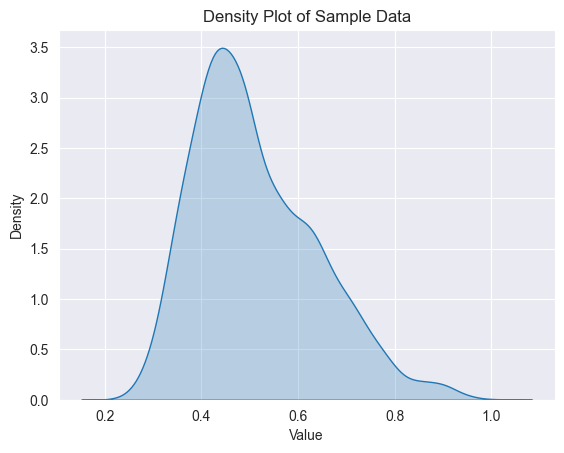

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a density plot
sns.kdeplot(gene_score['cosine'], fill=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Density Plot of Sample Data')
plt.show()

In [51]:
gene_score.drop(['Gene'], axis=1).corr()

,Drugability,Drugability_q,AD Gene,AD Drug,AD Pathway,Drug,btw,BT_q,Score,cosine
Drugability,1.000000,0.823303,-0.000391,0.039233,0.022722,-0.081371,-0.042531,-0.056840,0.340031,0.002589
Drugability_q,0.823303,1.000000,0.005214,0.052889,0.034754,-0.091002,-0.044667,-0.052707,0.431605,-0.002630
AD Gene,-0.000391,0.005214,1.000000,0.456340,0.600680,-0.195345,-0.298434,-0.440029,0.574570,0.020676
AD Drug,0.039233,0.052889,0.456340,1.000000,0.496783,-0.307717,-0.275822,-0.452406,0.500963,-0.005188
AD Pathway,0.022722,0.034754,0.600680,0.496783,1.000000,-0.240899,-0.265346,-0.417508,0.599614,0.007901
Drug,-0.081371,-0.091002,-0.195345,-0.307717,-0.240899,1.000000,0.229298,0.350849,0.199992,0.008860
btw,-0.042531,-0.044667,-0.298434,-0.275822,-0.265346,0.229298,1.000000,0.681680,0.050429,-0.009210
BT_q,-0.056840,-0.052707,-0.440029,-0.452406,-0.417508,0.350849,0.681680,1.000000,0.052578,-0.005318
Score,0.340031,0.431605,0.574570,0.500963,0.599614,0.199992,0.050429,0.052578,1.000000,0.009417
cosine,0.002589,-0.002630,0.020676,-0.005188,0.007901,0.008860,-0.009210,-0.005318,0.009417,1.000000


# Node2Vec
It's been moved to HPC. GPU on HPC accelerates Node2Vec.

# Test - Edge2Vec Class

In [24]:
%load_ext autoreload
%autoreload 2
import networkx as nx
from util import read_graph, Edge2Vec

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'bayanpy', 'leidenalg', 'infomap', 'graph_tool'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap', 'leidenalg'}


In [25]:
HetionetG = read_graph('./hetio_edge2vec_input.csv', directed=True)

In [4]:
HetionetG.number_of_edges()

2110272

In [74]:
args = {
	'type_size': 3,
    'em_iteration': 5,
	'e_step': 3,
	'dimensions': 10,
	'walk_length': 3,
	'num_walks': 2,
	'window_size': 5,
	'iter': 10,
	'workers': 8,
	'p': 1,
	'q': 1,
	'directed': False
}

In [106]:
edge2vec_trans = Edge2Vec(
	nxGraph=HetionetG,
	em_iteration=args['em_iteration'],
	e_step=args['e_step'],
	walk_length=args['walk_length'],
    num_walks=args['num_walks'],
	p=args['p'],
	q=args['q'],
	directed=args['directed']
)

In [108]:
trans_matrix = edge2vec_trans.gen_transition_matrix()

------begin to simulate walk---------


TypeError: Edge2Vec.simulate_walks() missing 1 required positional argument: 'self'